In [1]:
import os
import time
import warnings
import random
import glob
import pickle
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from skimage.feature import hog
from skimage.color import rgb2gray
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
plt.ion()

SEED = 12345
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
print('Seeds set to', SEED)

Seeds set to 12345


In [2]:
def load_pickle_image(file_path):
    with open(file_path, "rb") as f:
        return pickle.load(f)

file_paths = []
for vol in range(1, 9):
    folder = f"archive/vol{vol:02d}"
    file_paths += sorted(glob.glob(f"{folder}/*.pck"))

print(f"Found {len(file_paths)} total image files")

Found 736 total image files


In [3]:
meta = pd.read_csv("metadata.csv")
fn_to_label = dict(zip(meta['volumeFilename'], meta['aclDiagnosis']))
label_names = {0: 'Normal', 1: 'Torn'}

mapped = []
for p in file_paths:
    fname = os.path.basename(p)
    orig = fn_to_label.get(fname, None)
    if orig is None:
        label = None
    else:
        label = 1 if int(orig) == 2 else int(orig)
    mapped.append((p, label, label_names.get(label) if label is not None else None))

print("Label distribution (numeric):", Counter(l for _p, l, _n in mapped if l is not None))
print("Label distribution (names):", Counter(n for _p, l, n in mapped if n is not None))

Label distribution (numeric): Counter({0: 547, 1: 189})
Label distribution (names): Counter({'Normal': 547, 'Torn': 189})


In [4]:
MAX_SAMPLES = 400
IMG_SIZE = (64, 64)
hog_params = dict(orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))

paths_by_label = {}
for file_path, label, _name in mapped:
    if label is None:
        continue
    paths_by_label.setdefault(label, []).append(file_path)

class_labels = sorted(paths_by_label.keys())
num_classes = len(class_labels)
print('Detected classes:', class_labels)

samples_per_class_target = max(1, MAX_SAMPLES // max(1, num_classes))

cache_dir = Path('cache')
cache_dir.mkdir(exist_ok=True)
cache_path = cache_dir / 'hog_features.npz'
rng = random.Random(SEED)

if cache_path.exists():
    print('Loading preprocessed data from', cache_path)
    cache_data = np.load(cache_path, allow_pickle=True)
    X_hog = cache_data['X_hog']
    y_labels = cache_data['y_labels']
else:
    hog_features_list = []
    labels_list = []
    t_start = time.time()
    for label in class_labels:
        file_paths_for_label = paths_by_label[label]
        if len(file_paths_for_label) == 0:
            continue
        n_take = min(len(file_paths_for_label), samples_per_class_target)
        chosen = (rng.sample(list(file_paths_for_label), n_take)
                  if n_take <= len(file_paths_for_label)
                  else [rng.choice(list(file_paths_for_label)) for _ in range(n_take)])
        for chosen_path in chosen:
            volume = load_pickle_image(chosen_path)
            volume_arr = np.asarray(volume)

            if volume_arr.ndim == 3 and volume_arr.shape[0] >= 3:
                center_idx = volume_arr.shape[0] // 2
                idxs = [max(0, center_idx - 1), center_idx,
                        min(volume_arr.shape[0] - 1, center_idx + 1)]
                channels = []
                for si in idxs:
                    s = volume_arr[si]
                    if s.ndim == 3:
                        s = rgb2gray(s)
                    s_res = resize(s, IMG_SIZE, anti_aliasing=True)
                    channels.append(s_res.astype(np.float32))
                slice_resized = channels[1]
            else:
                slice_resized = volume_arr[volume_arr.shape[0] // 2] if volume_arr.ndim == 3 else volume_arr
                if slice_resized.ndim == 3:
                    slice_resized = rgb2gray(slice_resized)
                slice_resized = resize(slice_resized, IMG_SIZE, anti_aliasing=True)

            hog_descriptor = hog(
                (slice_resized * 255).astype(np.uint8),
                orientations=hog_params['orientations'],
                pixels_per_cell=hog_params['pixels_per_cell'],
                cells_per_block=hog_params['cells_per_block'],
                visualize=False,
                feature_vector=True
            )
            hog_features_list.append(hog_descriptor)
            labels_list.append(label)

    t_end = time.time()
    print(f'Preprocessing done — {len(hog_features_list)} items in {t_end - t_start:.1f}s')
    if len(hog_features_list) > MAX_SAMPLES:
        hog_features_list = hog_features_list[:MAX_SAMPLES]
        labels_list = labels_list[:MAX_SAMPLES]
    X_hog = np.vstack(hog_features_list)
    y_labels = np.array(labels_list)
    np.savez_compressed(cache_path, X_hog=X_hog, y_labels=y_labels)
    print('Saved preprocessed cache to', cache_path)

print('Unique labels in dataset:', np.unique(y_labels))

X_hog_train, X_hog_test, y_hog_train, y_hog_test = train_test_split(
    X_hog, y_labels, test_size=0.2, stratify=y_labels, random_state=SEED
)
print(f'Train: {len(X_hog_train)}, Test: {len(X_hog_test)}')

Detected classes: [0, 1]
Preprocessing done — 389 items in 5.7s
Saved preprocessed cache to cache/hog_features.npz
Unique labels in dataset: [0 1]
Train: 311, Test: 78


In [5]:
epochs = 10
sgd_logr = SGDClassifier(loss='log_loss', random_state=SEED)
for epoch in range(epochs):
    sgd_logr.partial_fit(X_hog_train, y_hog_train, classes=np.unique(y_hog_train))

print('SGD-LogReg acc:', accuracy_score(y_hog_test, sgd_logr.predict(X_hog_test)))

labels_sorted = sorted(np.unique(y_hog_test))
label_names_for_report = [label_names.get(int(i), str(int(i))) for i in labels_sorted]
print('\nSGD-LogReg classification report:\n')
print(classification_report(
    y_hog_test, sgd_logr.predict(X_hog_test),
    labels=labels_sorted, target_names=label_names_for_report
))

SGD-LogReg acc: 0.5769230769230769

SGD-LogReg classification report:

              precision    recall  f1-score   support

      Normal       0.56      0.78      0.65        40
        Torn       0.61      0.37      0.46        38

    accuracy                           0.58        78
   macro avg       0.59      0.57      0.56        78
weighted avg       0.59      0.58      0.56        78



Accuracy: 0.5769  Precision: 0.6087  Recall: 0.3684  F1: 0.4590


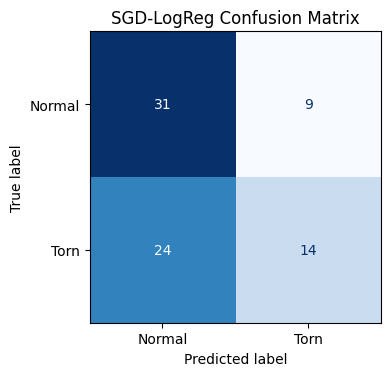

In [6]:
y_pred_logr = sgd_logr.predict(X_hog_test)

def _metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    return acc, prec, rec, f1

acc, prec, rec, f1 = _metrics(y_hog_test, y_pred_logr)
print(f'Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}')

cm = confusion_matrix(y_hog_test, y_pred_logr, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[label_names[0], label_names[1]]
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('SGD-LogReg Confusion Matrix')
plt.tight_layout()
plt.show()